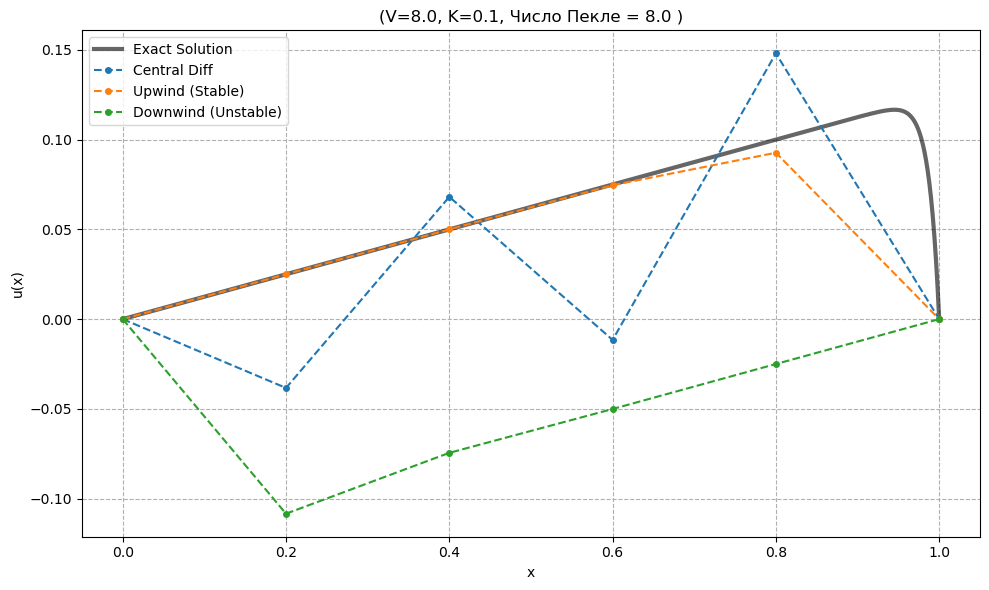

In [17]:
import numpy as np
import matplotlib.pyplot as plt

K, V, L, N = 0.1, 8.0, 1.0, 5
# K, V, L, N = 0.1, 100.0, 1.0, 100
# K, V, L, N = 10, 100, 1, 100
# K, V, L, N = 0.1, 100.0, 1.0, 100
# K, V, L, N = 10, 100.0, 1.0, 100

N_acc = 500

h = L / N
X = np.linspace(0, L, N + 1)
X_acc = np.linspace(0, L, N_acc + 1)


def solve(scheme_type):
    A = np.zeros((N + 1, N + 1))
    b = np.ones(N + 1)
    
    for i in range(1, N):
        diff_2 = K / h**2
        conv = V / (2 * h) if scheme_type == 'central' else V / h
        
        if scheme_type == 'central':
            A[i, i-1], A[i, i], A[i, i+1] = -diff_2 - conv, 2 * diff_2, -diff_2 + conv
        elif scheme_type == 'upwind':
            A[i, i-1], A[i, i], A[i, i+1] = -diff_2 - conv, 2 * diff_2 + conv, -diff_2
        elif scheme_type == 'downwind':
            A[i, i-1], A[i, i], A[i, i+1] = -diff_2, 2 * diff_2 - conv, -diff_2 + conv

    A[0, 0] = A[-1, -1] = 1
    b[0] = b[-1] = 0
    return np.linalg.solve(A, b)

def get_exact(x, k, v):
    # if abs(v) < 1e-10: return 0.5 * x * (1 - x) / k
    return (1/v) * (x - (np.exp(v*x/k) - 1) / (np.exp(v/k) - 1))

schemes = {
    'central': 'Central Diff',
    'upwind': 'Upwind (Stable)',
    'downwind': 'Downwind (Unstable)'
}

fig, ax = plt.subplots(figsize=(10, 6))
u_exact = get_exact(X_acc, K, V)
ax.plot(X_acc, u_exact, 'k-', lw=3, label='Exact Solution', alpha=0.6)
for s_id, s_name in schemes.items():
    u_num = solve(s_id)
    ax.plot(X, u_num, 'o--', ms=4, label=s_name)
ax.set(title=f'(V={V}, K={K}, Число Пекле = {V*h/(2*K)} )', xlabel='x', ylabel='u(x)')
ax.legend(frameon=True, facecolor='white')
ax.grid(True, linestyle='--')

plt.tight_layout()
plt.show()